### Code Hist.

 - CODE  
    &ensp; : Model - KIER Method 02(Clustering)

  - DATE      &ensp; 2023-03-05 Created  
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 1) Dataset : KIER / KMA_ASOS    
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 2) Model : CatBoost  
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 3)   

 - Related Link  
    &ensp; : 

# 01. Code

## 01-01. Init

### 01-01-01. Init_Module Import

In [227]:
#region Basic_Import
## Basic
import os
os.path.dirname(os.path.abspath('__file__'))
import sys
sys.path.append(os.path.dirname(os.path.abspath(os.path.dirname('__file__'))))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pandas import DataFrame, Series

import math
import random

## Datetime
import time
import datetime as dt
from datetime import datetime, date, timedelta

import glob
from glob import glob
import requests
import json

## 시각화
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

from scipy import stats

# K-Means 알고리즘
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.model_selection import train_test_split

# CLustering 알고리즘의 성능 평가 측도
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score, silhouette_score, rand_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import contingency_matrix

## 정규화
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import metrics

import urllib
from urllib.request import urlopen
from urllib.parse import urlencode, unquote, quote_plus

from selenium import webdriver
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

## Init.
pd.options.display.float_format = '{:.10f}'.format
#endregion Basic_Import

In [ ]:
## Import_DL
str_tar = "tf"
## For Torch
if str_tar == "torch":
    import torch
    import torch.nn as nn
    from torch.nn.utils import weight_norm
    print("Torch Imported")
## For TF
elif str_tar == "tf":
    import tensorflow as tf
    import tensorflow_addons as tfa
    from keras.callbacks import EarlyStopping, ModelCheckpoint
    from keras.models import Sequential, load_model
    from keras_flops import get_flops
    print("Tensorflow Imported")
else:
    print("Error : Cannot be used except for Keywords")
    print(" : torch / tf")

Tensorflow Imported


In [229]:
print(tf.__version__)

2.10.0


In [230]:
# !pip install catboost

## LGBM
from catboost import Pool, CatBoostRegressor

# !pip install lightgbm

## LGBM
import lightgbm as lgbm
from lightgbm import LGBMRegressor

## XGBoost
import xgboost as xgb
from xgboost import plot_importance, plot_tree, XGBClassifier

In [231]:
## Import_Local
from core import data_datetime as com_date
from core import provider_kasi as com_Holi
from core import data_analysis as com_Analysis
from core import data_preprocessing as com_Prep
from core import data_visualization as com_Visual
from core import provider_kma as com_ASOS
from core import provider_kdhc as com_KDHC
from core import provider_kier as com_KIER

### 01-01-02. Config (Directory, Params)

In [232]:
## Init_config
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = "1"
random.seed(SEED)

In [233]:
## Define Todate str
str_now_ymd = pd.datetime.now().date()
str_now_y = pd.datetime.now().year
str_now_m = pd.datetime.now().month
str_now_d = pd.datetime.now().day
str_now_hr = pd.datetime.now().hour
str_now_min = pd.datetime.now().minute

print(pd.datetime.now())
print(str(str_now_y) + " / " + str(str_now_m)  + " / " + str(str_now_d))
print(str(str_now_hr) + " : " + str(str_now_min))

2024-03-07 16:38:49.408240
2024 / 3 / 7
16 : 38


In [234]:
## Dict_Domain
dict_domain = {0:"ELEC", 1:"HEAT", 2:"WATER", 3:"HOT_HEAT", 4:"HOT_FLOW", 99:"GAS"} ## GAS는 사용하지 않음.
int_domain = 2
str_domain = str(dict_domain[int_domain])

dict_col_accu = {0 : "ACTUAL_ACCU_EFF" ## ELEC
                 , 1 : "ACCU_HEAT" ## HEAT
                 , 2 : "ACCU_FLOW" ## WATER
                 , 3 : "ACCU_HEAT" ## HOT 열량
                 , 4 : "ACCU_FLOW" ## HOT 유량
                 , 99 : "ACCU_FLOW" ## GAS
                 }
str_col_accu = str(str_domain + "_" + str(dict_col_accu[int_domain]))

dict_col_inst = {0 : "INST_EFF" ## ELEC_ACCU/INST_EFF
                , 1 : "INST_HEAT" ## HEAT_ACCU/INST_HEAT
                , 2 : "INST_FLOW" ## WATER_ACCU/INST_FLOW
                , 3 : "INST_HEAT" ## HOT_ACCU/INST_HEAT
                , 4 : "INST_FLOW" ## HOT_ACCU/INST_FLOW
                , 99 : "INST_FLOW" ## GAS_ACCU/INST_FLOW
                } 
str_col_inst = str(str_domain + "_" + str(dict_col_inst[int_domain]))

## Directory Root
str_dirData = "../data/data_Energy_KIER/"
str_dir_raw = '../data/data_Energy_KIER/KIER_0_Raw/'
str_dirName_bld = '../data/data_Energy_KIER/KIER_1_BLD/'
str_dirName_f = '../data/data_Energy_KIER/KIER_2_F_' + str_domain + '/'
str_dirName_h = '../data/data_Energy_KIER/KIER_3_H_' + str_domain + '/'

## File
str_fileRaw = str('KIER_RAW_' + str_domain + '_2023-11-12.csv')
str_fileRaw_hList = str('KIER_hList_' + str_domain + '.csv')

print(str(os.listdir(str_dirData)) + "\n")
print(os.listdir(str_dirName_h))

['.ipynb_checkpoints', 'BS_CONFIGURATION_202309251452.csv', 'Data_Population_SJ_2014_2018_1st_Interpolated.csv', 'Data_Population_SJ_2014_2018_D_1st_Interpolated.csv', 'Data_Population_SJ_2014_2018_H_1st_Interpolated.csv', 'DATE_1M_2023-10-20.csv', 'ENV_SENSOR_HST_202309251452.csv', 'F1_MAIN_POWER_HST_202309251503.csv', 'F1_SUB_POWER_HST_202309251510.csv', 'HEATPUMP_HST_202309251520.csv', 'KIER_0_Raw', 'KIER_1_BLD', 'KIER_2_F_ELEC', 'KIER_2_F_GAS', 'KIER_2_F_HEAT', 'KIER_2_F_HOT', 'KIER_2_F_WATER', 'KIER_3_H_ELEC', 'KIER_3_H_GAS', 'KIER_3_H_HEAT', 'KIER_3_H_HOT', 'KIER_3_H_HOT_FLOW', 'KIER_3_H_HOT_HEAT', 'KIER_3_H_WATER', 'KIER_ASOS_WEATHER_DAILY_202309251521.csv', 'KIER_ASOS_WEATHER_HOUR_202309251521.csv', 'KIER_List_Table_Column_2023-09-25.xlsx', 'KIER_Query_2023-09-25.txt', 'KMA_ASOS_119_2010_2023_1st_to CSV.csv', 'LIGHT_HST_202309251523.csv', 'MACHINE_ROOM_HEAT_HST_202309251534.csv', 'MACHINE_ROOM_POWER_APT_HST_20221205_202309251617.csv', 'MACHINE_ROOM_POWER_APT_HST_20221205_202309

## 01-02. Data Load (df_raw)

### 01-02-01. KDHC Heat Usage (Intergrated)

In [235]:
## KMA_ASOS Data
str_dir_kmaAsos = "../data/data_KMA_ASOS/"

## Interpolate / Filled ASOS Data
str_file = 'ASOS_119_2010-2024_HR_INTP.csv'
Data_ASOS = pd.read_csv(str_dir_kmaAsos + str_file
                        , index_col = 0)
Data_ASOS['METER_DATE'] = pd.to_datetime(Data_ASOS['METER_DATE'])
Data_ASOS

,temp_outdoor,temp_dew_point,temp_ground,humidity,rainfall,snowfall,snowfall_3hr,wind_speed,wind_direction,pressure_vapor,...,solar_radiation,cloud_total,cloud_midlow,visual_range,YEAR,MONTH,DAY,HOUR,None,METER_DATE
0,-10.3000000000,-17.6000000000,-5.8000000000,55.0000000000,0.0000000000,0.5000000000,0.0000000000,1.6000000000,340.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,0,0,2010-01-01 00:00:00
1,-10.4000000000,-17.9000000000,-5.7000000000,54.0000000000,0.0000000000,0.5000000000,0.0000000000,0.3000000000,0.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,2010,1,1,1,0,2010-01-01 01:00:00
2,-10.6000000000,-17.6000000000,-5.9000000000,56.0000000000,0.0000000000,0.5000000000,0.0000000000,0.6000000000,270.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,2010,1,1,2,0,2010-01-01 02:00:00
3,-11.0000000000,-18.0000000000,-5.9000000000,56.0000000000,0.0000000000,0.5000000000,0.0000000000,1.5000000000,290.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,3,0,2010-01-01 03:00:00
4,-11.6000000000,-18.2000000000,-6.0000000000,58.0000000000,0.0000000000,0.5000000000,0.0000000000,0.9000000000,290.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,4,0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8656,2.1000000000,0.3000000000,-0.3000000000,88.0000000000,0.0000000000,0.0000000000,0.0000000000,0.5000000000,270.0000000000,6.2000000000,...,0.0000000000,0.0000000000,0.0000000000,2055.0000000000,2023,12,31,19,0,2023-12-31 19:00:00
8657,1.1000000000,0.0000000000,-0.3000000000,92.0000000000,0.0000000000,0.0000000000,0.0000000000,0.3000000000,0.0000000000,6.1000000000,...,0.0000000000,0.0000000000,0.0000000000,1447.0000000000,2023,12,31,20,0,2023-12-31 20:00:00
8658,0.0000000000,-0.7000000000,-0.4000000000,95.0000000000,0.0000000000,0.0000000000,0.0000000000,0.9000000000,270.0000000000,5.8000000000,...,0.0000000000,0.0000000000,0.0000000000,533.0000000000,2023,12,31,21,0,2023-12-31 21:00:00
8659,-0.5000000000,-1.0000000000,-0.6000000000,96.0000000000,0.0000000000,0.0000000000,0.0000000000,0.9000000000,230.0000000000,5.7000000000,...,0.0000000000,0.0000000000,0.0000000000,533.0000000000,2023,12,31,22,0,2023-12-31 22:00:00


In [236]:
## Cluster 기준 Interval
list_interval = ['10MIN', '1H', '1DAY', '1WEEK', '1MONTH']
str_interval = list_interval[4]
str_file_clustering = 'KIER_' + str(str_domain) + '_Labeled_' + str_interval + '.csv'
df_kier_h_cluster = pd.read_csv(str_dirName_h + str_file_clustering
                                , index_col = 0).rename(columns = {'index' : 'h_index'})[['h_index', 'target_' + str_domain]]
print(str_interval)
print(df_kier_h_cluster['target_' + str_domain].drop_duplicates())
df_kier_h_cluster

1MONTH
0    0
1    2
7    1
Name: target_WATER, dtype: int64


,h_index,target_WATER
0,WATER_INST_FLOW_561-1-1,0
1,WATER_INST_FLOW_561-1-2,2
2,WATER_INST_FLOW_561-1-3,2
3,WATER_INST_FLOW_561-1-4,2
4,WATER_INST_FLOW_561-2-1,2
...,...,...
343,WATER_INST_FLOW_563-23-2,2
344,WATER_INST_FLOW_563-23-3,1
345,WATER_INST_FLOW_563-23-4,0
346,WATER_INST_FLOW_563-24-1,0


In [237]:
list_kier_h_all = df_kier_h_cluster['h_index']
print(len(list_kier_h_all))
list_kier_h_c0 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 0]['h_index']
print(len(list_kier_h_c0))
list_kier_h_c1 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 1]['h_index']
print(len(list_kier_h_c1))
list_kier_h_c2 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 2]['h_index']
print(len(list_kier_h_c2))

348
68
115
165


In [238]:
## 사용량 Data Load
## 1시간 단위
str_file = 'KIER_' + str_domain + '_INST_1H_InstBaseUpdated.csv'
df_raw = pd.read_csv(str_dirName_h + str_file
                     , index_col = 0)
df_raw

,METER_DATE,WATER_INST_FLOW_561-1-1,WATER_INST_FLOW_561-1-2,WATER_INST_FLOW_561-1-3,WATER_INST_FLOW_561-1-4,WATER_INST_FLOW_561-2-1,WATER_INST_FLOW_561-2-2,WATER_INST_FLOW_561-2-3,WATER_INST_FLOW_561-2-4,WATER_INST_FLOW_561-3-1,...,WATER_INST_FLOW_563-22-3,WATER_INST_FLOW_563-22-4,WATER_INST_FLOW_563-22-5,WATER_INST_FLOW_563-22-6,WATER_INST_FLOW_563-23-1,WATER_INST_FLOW_563-23-2,WATER_INST_FLOW_563-23-3,WATER_INST_FLOW_563-23-4,WATER_INST_FLOW_563-24-1,WATER_INST_FLOW_563-24-2
0,2022-07-17 23:00:00,0.0145000000,0.0000000000,0.0000000000,0.0714467949,0.0044978263,0.0084168086,0.0000000000,0.0137000000,0.0024467949,...,0.0487000000,0.0253000000,0.0115000000,0.0000000000,0.0000000000,0.0001000000,0.0012000000,0.0034039877,0.0001000000,0.0039743347
1,2022-07-18 00:00:00,0.1097000000,0.0099000000,0.0026725692,0.0120568264,0.0216000000,0.0074174515,0.0000000000,0.0000000000,0.0046969387,...,0.0002000000,0.0364000000,0.0018802930,0.0125000000,0.0068000000,0.0090000000,0.0286000000,0.0004000000,0.0030566576,0.0000000000
2,2022-07-18 01:00:00,0.0410000000,0.0000000000,0.0013457277,0.0351000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0138139394,...,0.0094000000,0.0000000000,0.0001000000,0.0000000000,0.0011989859,0.0001000000,0.0001000000,0.0001000000,0.0012989859,0.0000000000
3,2022-07-18 02:00:00,0.0011624749,0.0000000000,0.0000000000,0.0455244491,0.0110000000,0.0014214162,0.0000000000,0.0144624749,0.0006342183,...,0.0000000000,0.0000000000,0.0004000000,0.0000000000,0.0001000000,0.0089000000,0.0000000000,0.0000000000,0.0275000000,0.0001000000
4,2022-07-18 03:00:00,0.0000000000,0.0000000000,0.0000000000,0.0194858345,0.0000000000,0.0013455649,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0003000000,0.0000000000,0.0069000000,0.0118000000,0.0000000000,0.0012858345,0.0009000000,0.0071000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10787,2023-10-10 10:00:00,0.0003000000,0.0619000000,0.0000000000,0.0000000000,0.0000000000,0.0262000000,0.0000000000,0.0153000000,0.0197000000,...,0.0000000000,0.0000000000,0.0789000000,0.0666000000,0.0142000000,0.0002000000,0.0002000000,0.0162000000,0.0087000000,0.0003000000
10788,2023-10-10 11:00:00,0.0000000000,0.0579000000,0.0000000000,0.0008000000,0.0524000000,0.0043000000,0.0000000000,0.0308000000,0.0481000000,...,0.0000000000,0.0322000000,0.0837000000,0.0371000000,0.0553000000,0.0003000000,0.0000000000,0.0283000000,0.0004000000,0.0004000000
10789,2023-10-10 12:00:00,0.0520000000,0.0005000000,0.0422000000,0.0000000000,0.1113000000,0.0084000000,0.0000000000,0.0004000000,0.0547000000,...,0.0115000000,0.0000000000,0.0212000000,0.0074000000,0.0431000000,0.0001000000,0.0000000000,0.0587000000,0.0005000000,0.0290000000
10790,2023-10-10 13:00:00,0.0493000000,0.0000000000,0.0000000000,0.0000000000,0.0094000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0157000000,0.0000000000,0.0000000000,0.0000000000,0.0108000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000


In [239]:
## 전체 사용량 합계
df_kier_h_all = df_raw.copy()
df_kier_h_all['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_all]
df_kier_h_all[str_domain + '_INST_SUM_ALL'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_all = df_kier_h_all[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_all[str_domain + '_INST_SUM_ALL'] = df_kier_h_all[str_domain + '_INST_SUM_ALL'].shift(1)
df_kier_h_all.dropna()

,METER_DATE,WATER_INST_FLOW_561-1-1,WATER_INST_FLOW_561-1-2,WATER_INST_FLOW_561-1-3,WATER_INST_FLOW_561-1-4,WATER_INST_FLOW_561-2-1,WATER_INST_FLOW_561-2-2,WATER_INST_FLOW_561-2-3,WATER_INST_FLOW_561-2-4,WATER_INST_FLOW_561-3-1,...,WATER_INST_FLOW_563-22-4,WATER_INST_FLOW_563-22-5,WATER_INST_FLOW_563-22-6,WATER_INST_FLOW_563-23-1,WATER_INST_FLOW_563-23-2,WATER_INST_FLOW_563-23-3,WATER_INST_FLOW_563-23-4,WATER_INST_FLOW_563-24-1,WATER_INST_FLOW_563-24-2,WATER_INST_SUM_ALL
1,2022-07-18 00:00:00,0.1097000000,0.0099000000,0.0026725692,0.0120568264,0.0216000000,0.0074174515,0.0000000000,0.0000000000,0.0046969387,...,0.0364000000,0.0018802930,0.0125000000,0.0068000000,0.0090000000,0.0286000000,0.0004000000,0.0030566576,0.0000000000,4.7959280401
2,2022-07-18 01:00:00,0.0410000000,0.0000000000,0.0013457277,0.0351000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0138139394,...,0.0000000000,0.0001000000,0.0000000000,0.0011989859,0.0001000000,0.0001000000,0.0001000000,0.0012989859,0.0000000000,2.8377319532
3,2022-07-18 02:00:00,0.0011624749,0.0000000000,0.0000000000,0.0455244491,0.0110000000,0.0014214162,0.0000000000,0.0144624749,0.0006342183,...,0.0000000000,0.0004000000,0.0000000000,0.0001000000,0.0089000000,0.0000000000,0.0000000000,0.0275000000,0.0001000000,1.3364364625
4,2022-07-18 03:00:00,0.0000000000,0.0000000000,0.0000000000,0.0194858345,0.0000000000,0.0013455649,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0003000000,0.0000000000,0.0069000000,0.0118000000,0.0000000000,0.0012858345,0.0009000000,0.0071000000,1.4545331732
5,2022-07-18 04:00:00,0.0288099595,0.0092000000,0.0000000000,0.0363000000,0.0000000000,0.0000000000,0.0268000000,0.0018099595,0.0000000000,...,0.0000000000,0.0004000000,0.0000000000,0.0337960644,0.0403000000,0.0003000000,0.0004000000,0.0006000000,0.0012000000,1.3296235267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10786,2023-10-10 09:00:00,0.0137000000,0.0323000000,0.0740000000,0.0009000000,0.0000000000,0.0024000000,0.0000000000,0.0006000000,0.0055000000,...,0.0002000000,0.1688000000,0.0118000000,0.0366000000,0.0001000000,0.0000000000,0.1325000000,0.0357000000,0.0005000000,8.3382391931
10787,2023-10-10 10:00:00,0.0003000000,0.0619000000,0.0000000000,0.0000000000,0.0000000000,0.0262000000,0.0000000000,0.0153000000,0.0197000000,...,0.0000000000,0.0789000000,0.0666000000,0.0142000000,0.0002000000,0.0002000000,0.0162000000,0.0087000000,0.0003000000,8.0466000000
10788,2023-10-10 11:00:00,0.0000000000,0.0579000000,0.0000000000,0.0008000000,0.0524000000,0.0043000000,0.0000000000,0.0308000000,0.0481000000,...,0.0322000000,0.0837000000,0.0371000000,0.0553000000,0.0003000000,0.0000000000,0.0283000000,0.0004000000,0.0004000000,6.2537000000
10789,2023-10-10 12:00:00,0.0520000000,0.0005000000,0.0422000000,0.0000000000,0.1113000000,0.0084000000,0.0000000000,0.0004000000,0.0547000000,...,0.0000000000,0.0212000000,0.0074000000,0.0431000000,0.0001000000,0.0000000000,0.0587000000,0.0005000000,0.0290000000,6.2039000000


In [240]:
## Cluster별 사용량 합계
## ■ C00
df_kier_h_c0 = df_raw.copy()[list_kier_h_c0]
df_kier_h_c0['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c0]
df_kier_h_c0[str_domain + '_INST_SUM_C0'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c0 = df_kier_h_c0[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c0[str_domain + '_INST_SUM_C0'] = df_kier_h_c0[str_domain + '_INST_SUM_C0'].shift(1)
df_kier_h_c0.dropna()

## ■ C01
df_kier_h_c1 = df_raw.copy()[list_kier_h_c1]
df_kier_h_c1['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c1]
df_kier_h_c1[str_domain + '_INST_SUM_C1'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c1 = df_kier_h_c1[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c1[str_domain + '_INST_SUM_C1'] = df_kier_h_c1[str_domain + '_INST_SUM_C1'].shift(1)
df_kier_h_c1.dropna()

## ■ C02
df_kier_h_c2 = df_raw.copy()[list_kier_h_c2]
df_kier_h_c2['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c2]
df_kier_h_c2[str_domain + '_INST_SUM_C2'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c2 = df_kier_h_c2[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c2[str_domain + '_INST_SUM_C2'] = df_kier_h_c2[str_domain + '_INST_SUM_C2'].shift(1)
df_kier_h_c2.dropna()

,WATER_INST_FLOW_561-1-2,WATER_INST_FLOW_561-1-3,WATER_INST_FLOW_561-1-4,WATER_INST_FLOW_561-2-1,WATER_INST_FLOW_561-2-2,WATER_INST_FLOW_561-2-3,WATER_INST_FLOW_561-3-1,WATER_INST_FLOW_561-3-3,WATER_INST_FLOW_561-4-1,WATER_INST_FLOW_561-4-2,...,WATER_INST_FLOW_563-20-4,WATER_INST_FLOW_563-20-5,WATER_INST_FLOW_563-21-5,WATER_INST_FLOW_563-21-6,WATER_INST_FLOW_563-22-2,WATER_INST_FLOW_563-23-1,WATER_INST_FLOW_563-23-2,WATER_INST_FLOW_563-24-2,METER_DATE,WATER_INST_SUM_C2
1,0.0099000000,0.0026725692,0.0120568264,0.0216000000,0.0074174515,0.0000000000,0.0046969387,0.0108000000,0.0062741091,0.0090000000,...,0.0002000000,0.0064000000,0.0000000000,0.0183802930,0.0001000000,0.0068000000,0.0090000000,0.0000000000,2022-07-18 00:00:00,2.1019891488
2,0.0000000000,0.0013457277,0.0351000000,0.0000000000,0.0000000000,0.0000000000,0.0138139394,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0297989859,0.0000000000,0.0175000000,0.0097000000,0.0011989859,0.0001000000,0.0000000000,2022-07-18 01:00:00,1.1487328061
3,0.0000000000,0.0000000000,0.0455244491,0.0110000000,0.0014214162,0.0000000000,0.0006342183,0.0000000000,0.0000000000,0.0000000000,...,0.0001000000,0.0001000000,0.0000000000,0.0090000000,0.0000000000,0.0001000000,0.0089000000,0.0001000000,2022-07-18 02:00:00,0.6239077427
4,0.0000000000,0.0000000000,0.0194858345,0.0000000000,0.0013455649,0.0000000000,0.0000000000,0.0000000000,0.0082000000,0.0000000000,...,0.0094000000,0.0059000000,0.0011839286,0.0168000000,0.0000000000,0.0069000000,0.0118000000,0.0071000000,2022-07-18 03:00:00,0.7488447596
5,0.0092000000,0.0000000000,0.0363000000,0.0000000000,0.0000000000,0.0268000000,0.0000000000,0.0000000000,0.0000000000,0.0088000000,...,0.0232000000,0.0003000000,0.0000000000,0.0109000000,0.0041960644,0.0337960644,0.0403000000,0.0012000000,2022-07-18 04:00:00,0.5914852798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10786,0.0323000000,0.0740000000,0.0009000000,0.0000000000,0.0024000000,0.0000000000,0.0055000000,0.0134000000,0.0201000000,0.0216000000,...,0.0010000000,0.0001000000,0.0105000000,0.0001000000,0.1634000000,0.0366000000,0.0001000000,0.0005000000,2023-10-10 09:00:00,3.4310391931
10787,0.0619000000,0.0000000000,0.0000000000,0.0000000000,0.0262000000,0.0000000000,0.0197000000,0.0000000000,0.0095000000,0.2662000000,...,0.0003000000,0.0001000000,0.0001000000,0.0200000000,0.1423000000,0.0142000000,0.0002000000,0.0003000000,2023-10-10 10:00:00,3.5845000000
10788,0.0579000000,0.0000000000,0.0008000000,0.0524000000,0.0043000000,0.0000000000,0.0481000000,0.0138000000,0.0113000000,0.0180000000,...,0.0115000000,0.0000000000,0.0000000000,0.0000000000,0.0564000000,0.0553000000,0.0003000000,0.0004000000,2023-10-10 11:00:00,2.6540000000
10789,0.0005000000,0.0422000000,0.0000000000,0.1113000000,0.0084000000,0.0000000000,0.0547000000,0.0405000000,0.0180000000,0.0005000000,...,0.0001000000,0.0399000000,0.0000000000,0.0102000000,0.0117000000,0.0431000000,0.0001000000,0.0290000000,2023-10-10 12:00:00,2.5576000000


In [241]:
# 에너지 사용량 총계만
# df_kier_h_all = df_kier_h_all[['METER_DATE', str_domain + '_INST_SUM_ALL']].dropna()

# df_kier_h_c0 = df_kier_h_c0[['METER_DATE', str_domain + '_INST_SUM_C0']].dropna()

# df_kier_h_c1 = df_kier_h_c1[['METER_DATE', str_domain + '_INST_SUM_C1']].dropna()

# df_kier_h_c2 = df_kier_h_c2[['METER_DATE', str_domain + '_INST_SUM_C2']].dropna()


In [242]:
## 날씨 데이터 추가
df_kier_h_all = pd.merge(df_kier_h_all, Data_ASOS
                         , how = 'left', on = ['METER_DATE'])
df_kier_h_c0 = pd.merge(df_kier_h_c0, Data_ASOS
                        , how = 'left', on = ['METER_DATE'])
df_kier_h_c1 = pd.merge(df_kier_h_c1, Data_ASOS
                        , how = 'left', on = ['METER_DATE'])
df_kier_h_c2 = pd.merge(df_kier_h_c2, Data_ASOS
                        , how = 'left', on = ['METER_DATE'])

In [243]:
print(df_kier_h_all.shape)
print(df_kier_h_all.columns)
print(df_kier_h_c0.shape)
print(df_kier_h_c0.columns)
print(df_kier_h_c1.shape)
print(df_kier_h_c1.columns)
print(df_kier_h_c2.shape)
print(df_kier_h_c2.columns)

(10791, 372)
Index(['METER_DATE', 'WATER_INST_FLOW_561-1-1', 'WATER_INST_FLOW_561-1-2',
       'WATER_INST_FLOW_561-1-3', 'WATER_INST_FLOW_561-1-4',
       'WATER_INST_FLOW_561-2-1', 'WATER_INST_FLOW_561-2-2',
       'WATER_INST_FLOW_561-2-3', 'WATER_INST_FLOW_561-2-4',
       'WATER_INST_FLOW_561-3-1',
       ...
       'sunshine', 'solar_radiation', 'cloud_total', 'cloud_midlow',
       'visual_range', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'None'],
      dtype='object', length=372)
(10791, 92)
Index(['WATER_INST_FLOW_561-1-1', 'WATER_INST_FLOW_561-5-1',
       'WATER_INST_FLOW_561-5-2', 'WATER_INST_FLOW_561-5-3',
       'WATER_INST_FLOW_561-5-4', 'WATER_INST_FLOW_561-7-1',
       'WATER_INST_FLOW_561-7-3', 'WATER_INST_FLOW_561-12-3',
       'WATER_INST_FLOW_561-16-1', 'WATER_INST_FLOW_561-16-3',
       'WATER_INST_FLOW_561-17-1', 'WATER_INST_FLOW_561-18-3',
       'WATER_INST_FLOW_562-2-2', 'WATER_INST_FLOW_562-2-4',
       'WATER_INST_FLOW_562-3-1', 'WATER_INST_FLOW_562-4-3',
       'WATE

In [244]:
# df_dt = pd.DataFrame()
# df_dt['METER_DATE'] = pd.to_datetime(df_int_ALL['METER_DATE'])

# df_int_ALL = df_int_ALL[df_int_ALL.columns[18:].to_list()]
# df_int_ALL['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C0 = df_int_C0[df_int_C0.columns[18:].to_list()]
# df_int_C0['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C1 = df_int_C1[df_int_C1.columns[18:].to_list()]
# df_int_C1['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C2 = df_int_C2[df_int_C2.columns[18:].to_list()]
# df_int_C2['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_ALL

## 01-06. Data Split (Train/Test Setting)

In [245]:
## 모든 세대
df_raw = df_kier_h_all
str_col_tar = str_domain + '_INST_SUM_ALL'
## 모든 세대
# df_raw = df_kier_h_c0
# str_col_tar = str_domain + '_INST_SUM_C0'
## 모든 세대
# df_raw = df_kier_h_c1
# str_col_tar = str_domain + '_INST_SUM_C1'
## 모든 세대
# df_raw = df_kier_h_c2
# str_col_tar = str_domain + '_INST_SUM_C2'

# df_raw = com_date.create_col_ymdhm(df_raw, 'METER_DATE')
# df_raw = com_date.create_col_weekdays(df_raw, 'METER_DATE')

df_raw = df_raw.drop(columns = ['METER_DATE', 'DAY', 'None']).dropna()
# df_raw = df_raw.drop(columns = ['METER_DATE', 'day_of_the_week']).dropna()
# df_raw = df_raw.drop(columns = ['METER_DATE', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'None']).dropna()

trainSet_Origin, testSet_Origin = train_test_split(df_raw, test_size=0.3, shuffle=False)
print(trainSet_Origin.shape, testSet_Origin.shape)

(7483, 89) (3208, 89)


In [246]:
# df_raw['ELEC_INST_SUM_ALL'].mean()

In [247]:
df_raw.isna().sum()

WATER_INST_FLOW_561-1-1    0
WATER_INST_FLOW_561-5-1    0
WATER_INST_FLOW_561-5-2    0
WATER_INST_FLOW_561-5-3    0
WATER_INST_FLOW_561-5-4    0
                          ..
cloud_midlow               0
visual_range               0
YEAR                       0
MONTH                      0
HOUR                       0
Length: 89, dtype: int64

In [248]:
trainSet = trainSet_Origin
testSet = testSet_Origin

## Input / Target Split
trainXX = trainSet.drop([str_col_tar],axis=1)
trainYY = trainSet[[str_col_tar]]
testXX = testSet.drop([str_col_tar],axis=1)
testYY = testSet[[str_col_tar]]

In [249]:
trainXXindex = trainXX.index
trainXXcolumns = trainXX.columns

trainYYindex = trainYY.index
trainYYcolumns = trainYY.columns

testXXindex = testXX.index
testXXcolumns = testXX.columns

testYYindex = testYY.index
testYYcolumns = testYY.columns

In [250]:
d_trainXX=pd.DataFrame(trainXX, index=trainXXindex, columns=trainXXcolumns)
d_trainYY=trainYY

d_testXX=pd.DataFrame(testXX, index=testXXindex, columns=testXXcolumns)
d_testYY=testYY

## 01-07. Model

### 01-07-01. ML  
1) CatBoost
2) XGB
3) LightGBM
4) Decision Tree
5) Random Forest
6) 

#### 01-07-01-01. Grid Search

In [251]:
## Modeling, Model Training
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

## Grid Search
kfold = KFold(n_splits = 5, shuffle = False, random_state = None)

In [252]:
# ## CB
# regressor = CatBoostRegressor()
# param_grid = {'iterations': [500]
#               , 'depth': [4, 5, 6]
#               # , 'loss_function': ['Logloss', 'CrossEntropy']
#               # , 'loss_function': []
#               , 'l2_leaf_reg': np.logspace(-20, -19, 3)
#               , 'leaf_estimation_iterations': [10]
#               # , 'eval_metric': ['Accuracy']
#               , 'eval_metric': ['MAE', 'MAPE', 'RMSE', 'R2', 'MSLE']
#               # , 'use_best_model': ['True']
#               , 'logging_level':['Silent']
#               , 'random_seed': [42]}

# grid_cv = GridSearchCV(estimator = regressor, param_grid = param_grid, cv = kfold)
# grid_cv.fit(trainXX, trainYY)

# print("best_Param : ", grid_cv.best_params_)
# print("best_Sroce : {0:.4f}", grid_cv.best_score_)

#### 01-07-01-02. Model Analysis

In [253]:
import time
tm_start = time.time()

In [254]:
## CB
earlystopping = EarlyStopping(monitor='loss', patience=50)
checkpoint = ModelCheckpoint(moniter='loss',filepath='s2s_elec.h5')

model = CatBoostRegressor(iterations = 500, max_ctr_complexity = 4, random_seed = 0
                          , od_type = 'Iter', od_wait = 25, verbose = 50, depth = 4) #10000
## GridSearch Parameter (ALL)
# model = CatBoostRegressor(depth = 6, iterations = 500, l2_leaf_reg = 1e-20, leaf_estimation_iterations = 10, logging_level = 'Silent'
#                           , random_seed = 42)

catboost_model = model.fit(trainXX, trainYY, cat_features = [],eval_set=[(trainXX, trainYY)], callbacks=[earlystopping,checkpoint])

Learning rate set to 0.106599
0:	learn: 1.0068321	test: 1.0068321	best: 1.0068321 (0)	total: 2.08ms	remaining: 1.04s


50:	learn: 0.4371668	test: 0.4371668	best: 0.4371668 (50)	total: 66.7ms	remaining: 587ms
100:	learn: 0.3835242	test: 0.3835242	best: 0.3835242 (100)	total: 131ms	remaining: 518ms
150:	learn: 0.3571333	test: 0.3571333	best: 0.3571333 (150)	total: 188ms	remaining: 435ms
200:	learn: 0.3383958	test: 0.3383958	best: 0.3383958 (200)	total: 245ms	remaining: 364ms
250:	learn: 0.3230609	test: 0.3230609	best: 0.3230609 (250)	total: 301ms	remaining: 299ms
300:	learn: 0.3093683	test: 0.3093683	best: 0.3093683 (300)	total: 360ms	remaining: 238ms
350:	learn: 0.2970937	test: 0.2970937	best: 0.2970937 (350)	total: 416ms	remaining: 176ms
400:	learn: 0.2867163	test: 0.2867163	best: 0.2867163 (400)	total: 471ms	remaining: 116ms
450:	learn: 0.2768175	test: 0.2768175	best: 0.2768175 (450)	total: 528ms	remaining: 57.3ms
499:	learn: 0.2679880	test: 0.2679880	best: 0.2679880 (499)	total: 581ms	remaining: 0us

bestTest = 0.2679880234
bestIteration = 499



In [255]:
tm_code = time.time() - tm_start
print("time : ", tm_code)

time :  0.6838405132293701


In [256]:
model_pred = catboost_model.predict(testXX)
model_preds=np.reshape(model_pred,(-1,1))

d_actual = testYY.to_numpy()
d_actual = np.reshape(d_actual,(-1,1))

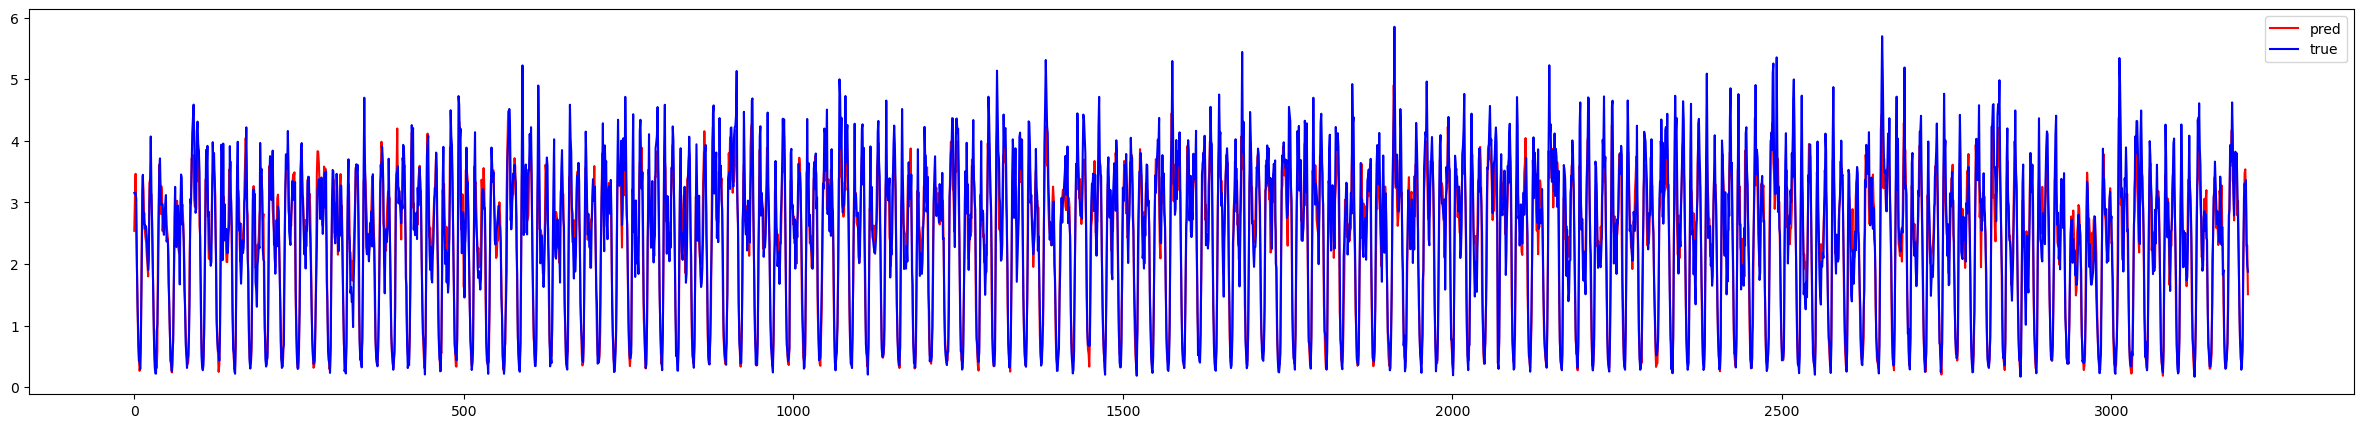

In [257]:
plt.figure(figsize=(30,5))
plt.plot(model_preds,color='red',label='pred')
plt.plot(d_actual,color='blue',label='true')
plt.legend()
plt.show()

In [258]:
## Code Time
print('TIME : ', tm_code)

com_Analysis.model_sk_metrics(d_actual, model_preds)

TIME :  0.6838405132293701
MAE  :  0.33198495753809726
MAPE :  0.16274154937407495
MSE  :  0.2000807355428069
RMSE :  0.447303851473254
MSLE :  0.014695007870553658
R2   :  0.8680392824488856


In [259]:
print(str_domain)
print(str_interval)
print(str_col_tar)

WATER
1MONTH
WATER_INST_SUM_C0


In [260]:
# ## Mean_Absolute_Error
# from sklearn.metrics import mean_absolute_error
# print('MAE  : ', mean_absolute_error(d_actual, model_preds))

# ## Mean_Absolute_Percentage_Error
# from sklearn.metrics import mean_absolute_percentage_error
# print('MAPE : ', mean_absolute_percentage_error(d_actual, model_preds))

# ## Mean_Squared_Error
# from sklearn.metrics import mean_squared_error
# print('MSE  : ', mean_squared_error(d_actual, model_preds))

# ## Root_Mean_Squared_Error
# from sklearn.metrics import mean_squared_error
# print('RMSE : ', mean_squared_error(d_actual, model_preds, squared = False))

# ## Mean_Squared_Log_Error
# from sklearn.metrics import mean_squared_log_error
# print('MSLE : ', mean_squared_log_error(d_actual, model_preds))

# ## R2_Score
# from sklearn.metrics import r2_score   # model.score
# print('R2   : ', r2_score(d_actual, model_preds))